BiLSTM_best_0.0638087096589583.pth


BiLSTM_best_0.0638087096589583.pth


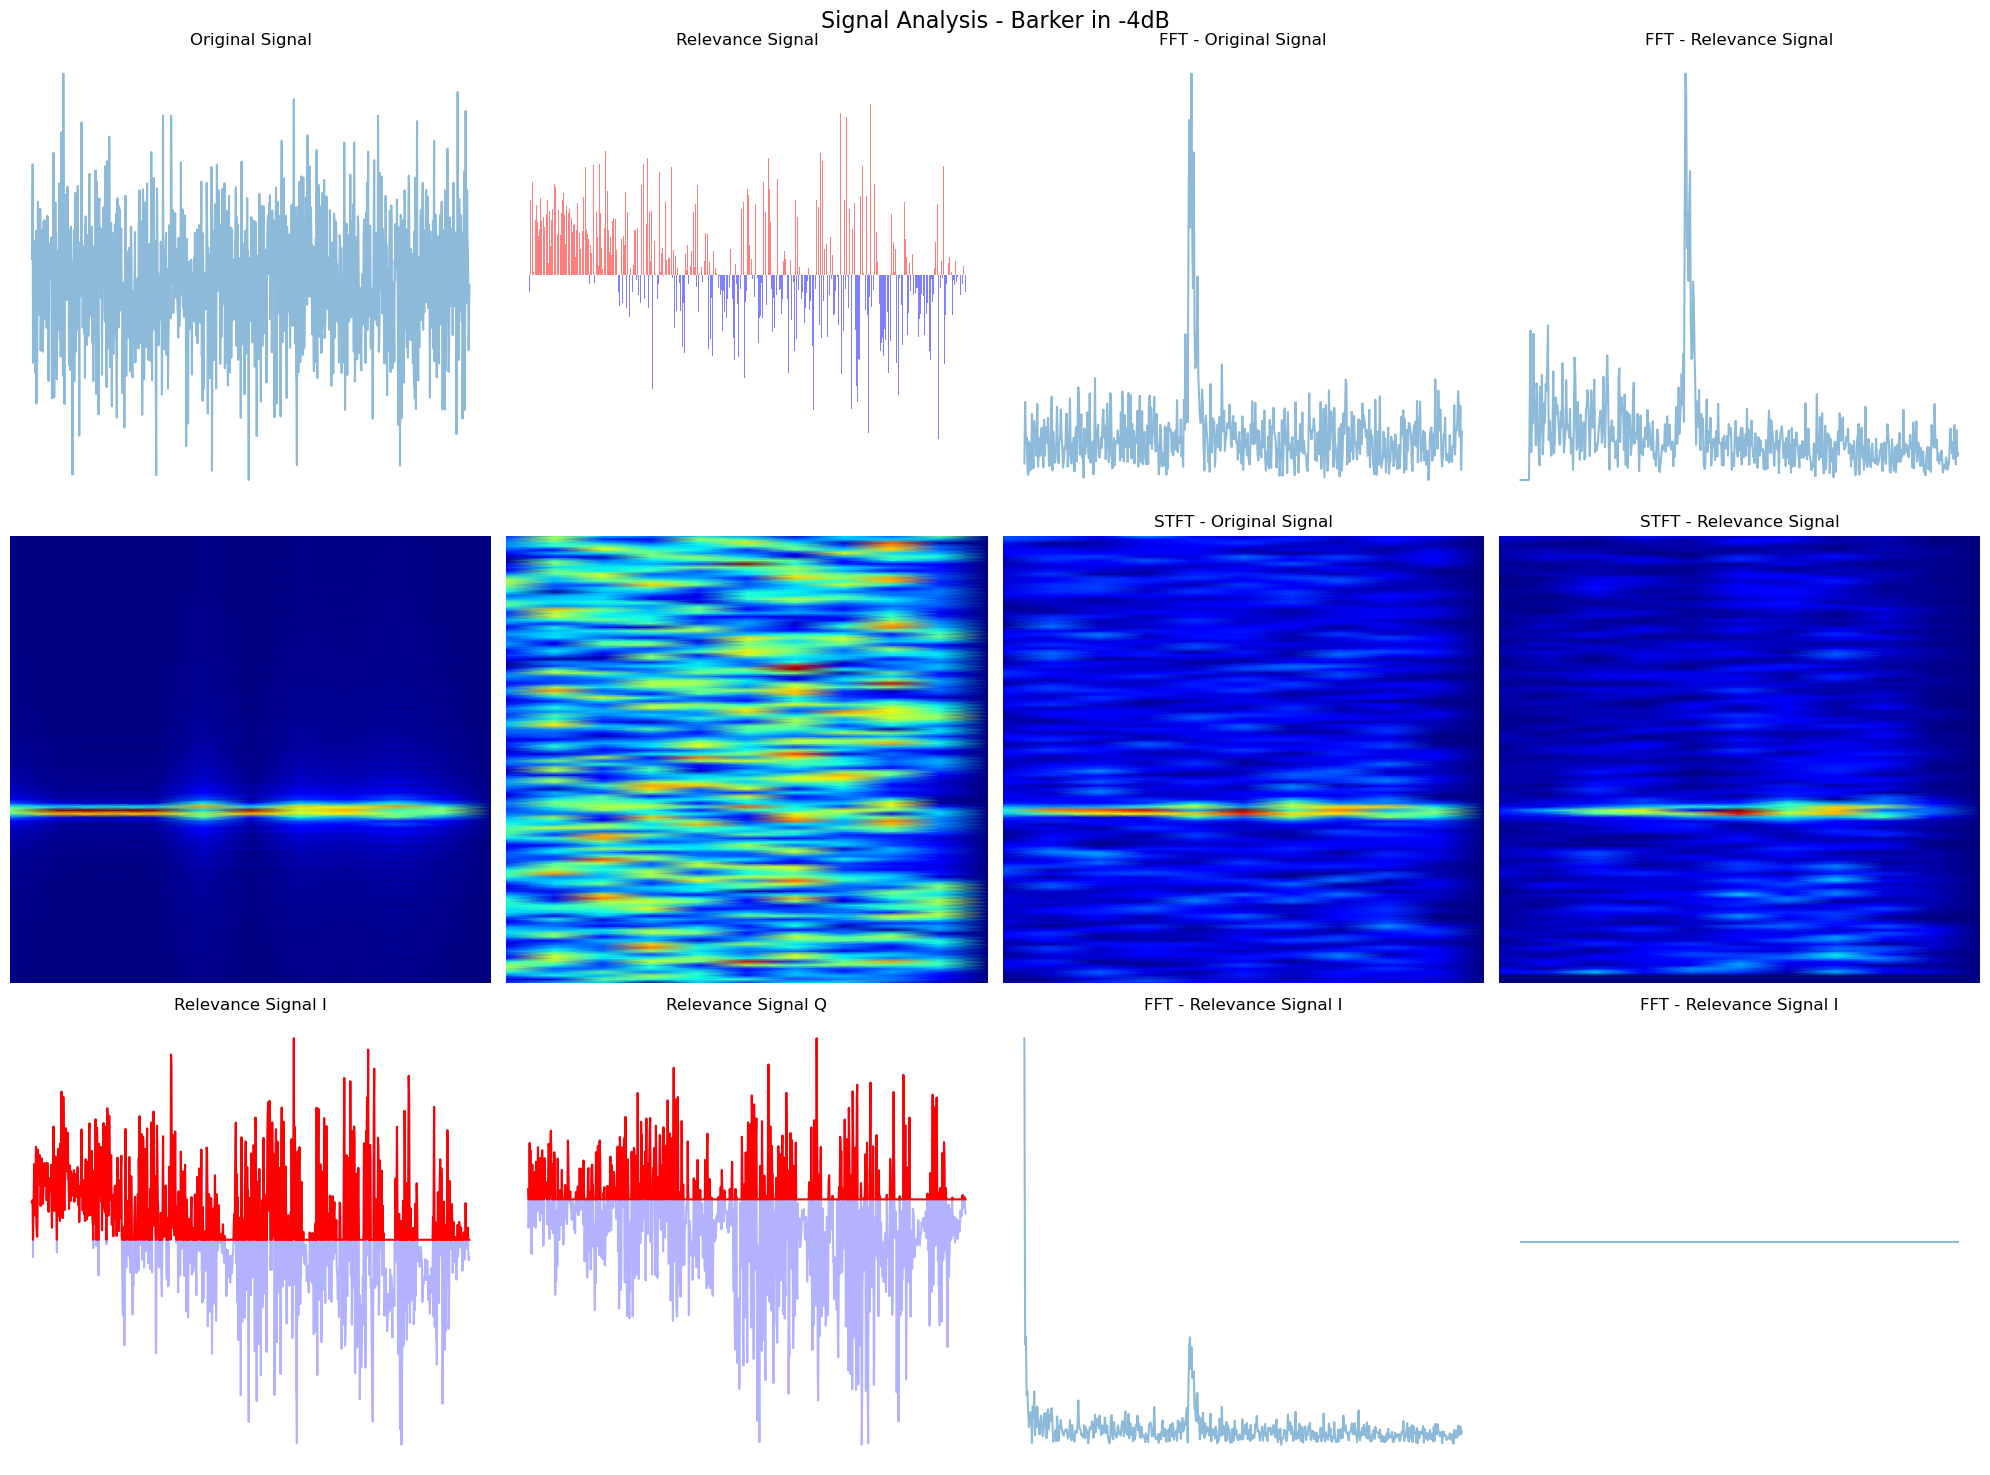

In [52]:
import os
import torch
import numpy as np
import models._config as c
import matplotlib.pyplot as plt

from models._config import *
from models.LSTM import BiLSTM
from dataset.LPIdataset import LPIDataset
from ex_models.LRP import LRP
from torch.utils.data import DataLoader
from warnings import filterwarnings
filterwarnings("ignore")

fs = 100e6
datatype = c.datatypes[-1]
test_dir = 'dataset/lpi_testset/'
dataset = LPIDataset(test_dir, c.waveforms, data_type=datatype, model_type='BiLSTM')
dataload = DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=c.collate)

model_type = c.modeltypes[0]
paths = [f for f in os.listdir(f'ckpts/{c.datatypes[-1]}/') if f.endswith('.pth') and f.startswith(model_type)]
best_ckpt = np.argmin([f.split('_')[-1] for f in paths])

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def load_models(path='./ckpts/result_loss.pt'):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    lrp = LRP(model, device=device, epsilon=1e-6)
    return model ,lrp


print(paths[best_ckpt])
model, lrp = load_models(path=f'ckpts/{c.datatypes[-1]}/{paths[best_ckpt]}')

import numpy as np

def moving_average_smoothing(relevance_scores, window_size=5):
    smoothed_scores = np.convolve(relevance_scores, np.ones(window_size)/window_size, mode='same')
    return smoothed_scores


with torch.no_grad():
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    for i, (data_batch, labels_batch, lengths_batch, snr_batch, idx_batch) in enumerate(dataload):
        data_batch = data_batch.to(device)
        labels_batch = labels_batch.to(device)
        rel_xb, gt_label = lrp.relevance(data_batch, lengths_batch)
        for j ,sample in enumerate(zip(data_batch, labels_batch, lengths_batch, snr_batch, idx_batch, rel_xb)):
            data, label, length, snr, idx, relevance = sample
            if gt_label[j] != label:
                continue
            
            r = 0
            xI, xQ = data[:length].cpu().numpy().T
            R_xI, R_xQ = relevance[:length].cpu().numpy().T
            x, R_x = comp(xI, xQ), comp(R_xI, R_xQ)

            axes[r, 0].plot(x, alpha=0.5)
            axes[r, 0].set_title(f'Original Signal')
            
            
            pos_indices = np.where(R_x > 0) 
            axes[r, 1].bar(pos_indices[0], R_x[pos_indices], alpha=0.5, color='red')

            neg_indices = np.where(R_x <= 0)
            axes[r, 1].bar(neg_indices[0], R_x[neg_indices], alpha=0.5, color='blue')
            axes[r, 1].set_title(f'Relevance Signal')
            
            
            fft_f, fft_a, fft = fft_transform(xI, xQ)
            R_fft_f, R_fft_a, R_fft = fft_transform(R_xI, R_xQ)
            R_fft_a = lowpass(R_fft_f, R_fft_a, cutoff=1e6)
            axes[r, 2].plot(fft_f, fft_a, alpha=0.5)
            axes[r, 2].set_title(f'FFT - Original Signal')
            axes[r, 3].plot(R_fft_f, R_fft_a, alpha=0.5)
            axes[r, 3].set_title(f'FFT - Relevance Signal')

            r = 1
            wav = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
            noise = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Noise_{idx}.npy')
            wf, ft, wZxx = stft_transform(np.load(wav).real, np.load(wav).imag, fs)
            nf, nt, nZxx = stft_transform(np.load(noise).real, np.load(noise).imag, fs)
            axes[r, 0].pcolormesh(ft, wf[:len(wf)//2], wZxx[:len(wf)//2], shading='gouraud', cmap='jet')
            axes[r, 1].pcolormesh(nt, nf[:len(nf)//2], nZxx[:len(nf)//2], shading='gouraud', cmap='jet')
            
            
            nper = 256
            f, t, Zxx = stft_transform(xI, xQ, fs, nper)
            rf, rt, rZxx = stft_transform(R_xI, R_xQ, fs, nper)
            rZxx = lowpass(rf, rZxx, cutoff=1e6)
            axes[r, 2].pcolormesh(t, f[:len(f)//2], Zxx[:len(f)//2], shading='gouraud', cmap='jet')
            axes[r, 2].set_title(f'STFT - Original Signal')
            axes[r, 3].pcolormesh(rt, rf[:len(rf)//2], rZxx[:len(rf)//2], shading='gouraud', cmap='jet')
            axes[r, 3].set_title(f'STFT - Relevance Signal')

            r = 2
            axes[r, 0].plot(R_xI, alpha=0.3, color='blue')
            axes[r, 0].set_title(f'Relevance Signal I')
            axes[r, 1].plot(R_xQ, alpha=0.3, color='blue')
            axes[r, 1].set_title(f'Relevance Signal Q')
            R_xI = np.where(R_xI <= 0, 0, R_xI)
            R_xQ = np.where(R_xQ <= 0, 0, R_xQ)
            axes[r, 0].plot(R_xI, color='red')
            axes[r, 1].plot(R_xQ, color='red')
            
            R_fft_f, R_fft_a, R_fft = fft_transform(R_xI, R_xQ)
            axes[r, 2].plot(R_fft_f, R_fft_a, alpha=0.5)
            axes[r, 2].set_title(f'FFT - Relevance Signal I')
            
            R_xI = np.where(R_xI > 0, 0, R_xI)
            R_xQ = np.where(R_xQ > 0, 0, R_xQ)
            R_fft_f, R_fft_a, R_fft = fft_transform(R_xI, R_xQ)
            axes[r, 3].plot(R_fft_f, R_fft_a, alpha=0.5)
            axes[r, 3].set_title(f'FFT - Relevance Signal I')
            
            
            
            
            fig.suptitle(f'Signal Analysis - {c.waveforms[label]} in {snr}dB', fontsize=16)
            for ax in axes.flatten():
                ax.axis('off')
            break
        
        break
        
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.UNET import UNet
from dataset.LPIdataset import LPIDataset
# from ex_models.LRP import UNetLRP
from torch.utils.data import DataLoader
import models._config as c

# 모델 로드 함수
def load_unet_model(path='./ckpts/result_loss.pt'):
    model = UNet(in_channels=1, out_channels=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    return model

import torch
import torch.nn.functional as F

class UNetLRP:
    def __init__(self, model, epsilon=1e-6):
        self.model = model
        self.epsilon = epsilon 

    def forward(self, x):
        """
        원본 UNet 모델을 통해 forward pass를 실행하고 feature map을 저장
        """
        e1 = self.model.encoder1(x)
        e2 = self.model.encoder2(F.max_pool2d(e1, 2))
        e3 = self.model.encoder3(F.max_pool2d(e2, 2))
        e4 = self.model.encoder4(F.max_pool2d(e3, 2))
        m = self.model.middle(F.max_pool2d(e4, 2))

        # 디코더 부분 및 skip connection 저장
        d4 = self.model.decoder4(torch.cat([F.interpolate(m, scale_factor=2), e4], dim=1))
        d3 = self.model.decoder3(torch.cat([F.interpolate(d4, scale_factor=2), e3], dim=1))
        d2 = self.model.decoder2(torch.cat([F.interpolate(d3, scale_factor=2), e2], dim=1))
        d1 = self.model.decoder1(torch.cat([F.interpolate(d2, scale_factor=2), e1], dim=1))

        pooled = self.model.global_pool(d1).view(d1.size(0), -1)
        output_logits = self.model.output(pooled)
        
        return output_logits, [d1, d2, d3, d4, m, e4, e3, e2, e1]

    def relevance_propagation(self, R):
        """
        relevance R을 입력으로 받아 모델의 각 층으로 relevance를 역전파
        """
        R = self.lrp_fc(self.model.output, R) 
        
        target_size = self.model.decoder1[0].output_shape  # 적절한 디코더 레이어 크기를 사용하여 target_size 설정
        R = self.lrp_conv_block(self.model.global_pool, R, target_size=target_size)
        R = self.lrp_decode(self.model.decoder1, R)
        R = self.lrp_decode(self.model.decoder2, R)
        R = self.lrp_decode(self.model.decoder3, R)
        R = self.lrp_decode(self.model.decoder4, R)
        
        
        R = self.lrp_conv_block(self.model.middle, R)
        R = self.lrp_encode(self.model.encoder4, R)
        R = self.lrp_encode(self.model.encoder3, R)
        R = self.lrp_encode(self.model.encoder2, R)
        R = self.lrp_encode(self.model.encoder1, R)
        
        return R

    def lrp_fc(self, layer, R):
        weight = layer.weight.T + self.epsilon
        Z = weight * R  
        S = R / (Z.sum(dim=0, keepdim=True) + self.epsilon) 
        print(S.shape)
        C = (weight * S).sum(dim=1, keepdim=True)
        return C
    
    def lrp_conv_block(self, layer, R, target_size=None):
        if isinstance(layer, torch.nn.AdaptiveAvgPool2d):
            if target_size is not None:
                R = F.interpolate(R, size=target_size, mode='nearest')
            else:
                raise ValueError("target_size must be provided for AdaptiveAvgPool2d layer in LRP.")
        else:
            # Conv 블록의 다른 레이어에서 relevance 역전파
            for conv_layer in reversed(layer):
                if isinstance(conv_layer, torch.nn.Conv2d):
                    R = self.propagate_conv2d(conv_layer, R)
        return R

    def propagate_conv2d(self, layer, R):
        Z = layer.weight * layer.input
        S = R / (Z + self.epsilon)
        C = Z * S
        return C.sum(dim=1)

    def lrp_decode(self, layer, R):
        """
        디코더 부분에서 skip connection과 함께 역전파
        """
        R = self.lrp_conv_block(layer, R)
        R = F.interpolate(R, scale_factor=2, mode='nearest')
        return R

    def lrp_encode(self, layer, R):
        """
        인코더 부분에서 relevance를 역전파
        """
        return self.lrp_conv_block(layer, R)


datatype = c.datatypes[-1]
test_dir = 'dataset/lpi_testset/STFT/'
dataset = LPIDataset(test_dir, c.waveforms, data_type=datatype, model_type='UNet')
dataload = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=c.collate)  

model = load_unet_model(path=f'ckpts/{datatype}/UNET_best_0.0165.pth')
lrp = UNetLRP(model)  # UNet용 LRP 객체 생성


def visualize_unet_lrp(lrp, dataloader):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    data_iter = iter(dataloader)
    data_batch, labels_batch, _, _, _ = next(data_iter)

    data_batch = data_batch.cuda()
    labels_batch = labels_batch.cuda()

    # LRP relevance 계산
    outputs, feature_maps = lrp.forward(data_batch)
    relevance_map = lrp.relevance_propagation(outputs)

    # STFT 이미지와 LRP 시각화
    stft_image = data_batch[0].cpu().numpy().squeeze()
    relevance_map = relevance_map[0].cpu().detach().numpy()

    # 원본 STFT 이미지
    axes[0, 0].imshow(stft_image, cmap='jet')
    axes[0, 0].set_title("Original STFT Image")
    axes[0, 0].axis("off")

    # # LRP 결과 히트맵
    # sns.heatmap(relevance_map, ax=axes[0, 1], cmap='jet', cbar=True)
    # axes[0, 1].set_title("LRP Relevance Map")
    # axes[0, 1].axis("off")

    # # 중요도가 높은 영역 강조 (Threshold 적용)
    # threshold = np.percentile(relevance_map, 90)  # 상위 10%로 설정
    # high_relevance_map = np.where(relevance_map >= threshold, relevance_map, 0)
    # sns.heatmap(high_relevance_map, ax=axes[1, 0], cmap='jet', cbar=True)
    # axes[1, 0].set_title("Top 10% Relevance Map")
    # axes[1, 0].axis("off")

    # # 상위 10% 영역을 원본 이미지 위에 중첩하여 시각화
    # axes[1, 1].imshow(stft_image, cmap='gray', alpha=0.6)
    # sns.heatmap(high_relevance_map, ax=axes[1, 1], cmap='jet', alpha=0.4, cbar=False)
    # axes[1, 1].set_title("Original Image with Top 10% Relevance Overlay")
    # axes[1, 1].axis("off")

    # fig.suptitle(f"LRP Analysis for {c.waveforms[labels_batch.item()]}")
    plt.tight_layout()
    plt.show()

# LRP 시각화 함수 호출
visualize_unet_lrp(lrp, dataload)


# CONFUSION MATRIX
학습 결과 검증 단계

In [ ]:
import os
import torch
import models._config as c
from models.LSTM import BiLSTM
from dataset.LPIdataset import LPIDataset
from ex_models.LRP import LRP
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def load_models(path='./ckpts/result_loss.pt'):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    return model

datatype = c.datatypes[-1]
test_dir = 'dataset/lpi_testset/'
dataset = LPIDataset(test_dir, c.waveforms, data_type=datatype)
dataload = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=c.collate)

paths = [f for f in os.listdir(f'ckpts/{datatype}/') if f.endswith('.pth')]
best_ckpt = np.argmin([f.split('_')[-1] for f in paths])

print(paths[best_ckpt])
model = load_models(path=f'ckpts/{datatype}/{paths[best_ckpt]}')

def evaluate_and_plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data_batch, labels_batch, lengths_batch in dataloader:
            data_batch = data_batch.cuda()
            labels_batch = labels_batch.cuda()

            outputs = model(data_batch, lengths_batch)
            preds = torch.argmax(outputs, dim=1)

            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    conf_matrix = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))
    conf_matrix = conf_matrix.astype(int)

    conf_matrix = np.nan_to_num(conf_matrix, nan=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 10})
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_and_plot_confusion_matrix(model, dataload, c.waveforms)


In [10]:
import os
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

class LPIDataset:
    def __init__(self, data_dir, waveforms, data_type='Signal', nperseg=256, model_type='BiLSTM'):
        self.data_dir = data_dir
        self.waveform = waveforms
        self.data_type = data_type
        self.file_list = self._collect()
        
        self.nperseg = nperseg  
        self.model_type = model_type
        self.resize_shape = (128, 128) 
        self.resize_transform = transforms.Compose([
            transforms.Resize(self.resize_shape),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor()
        ])

    def _collect(self):
        files = []
        all_files = []
        for waveform in self.waveform:
            waveform_folder = os.path.join(self.data_dir, waveform)
            files.extend([f for f in os.listdir(waveform_folder) if self.data_type in f or 'STFT' in f])
            
        return files

    def _parse(self, file):
        parts = os.path.splitext(file)[0].split('_') # 파일명에서 확장자 제거 후 '_'로 분리
        label = parts[0]
        snr = int(parts[1].replace('snr', ''))
        file_type = parts[2]
        fps_idx = int(parts[3])

        return file_type, label, snr, fps_idx

    def _convIQ(self, complex_data):
        return complex_data.real, complex_data.imag

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file = self.file_list[idx]
        file_type, label, snr, fps_idx = self._parse(file)
        
        if self.model_type == 'BiLSTM':
            # BiLSTM 모델의 경우 원본 시계열 데이터를 I/Q 분리하여 사용
            file_path = os.path.join(self.data_dir, label, file)
            complex_data = np.load(file_path)
            IQ_data = [self._convIQ(c) for c in complex_data]
            data_tensor = torch.tensor(IQ_data, dtype=torch.float32)
            length = len(data_tensor)  # 시퀀스 길이 반환
            return data_tensor, label, length, snr, fps_idx

        elif self.model_type in ['UNet', 'U2Net']:
            # UNet 및 U2Net 모델의 경우 STFT 이미지 파일 사용
            img_path = os.path.join(self.data_dir, label, file)

            image = Image.open(img_path)
            image = self.resize_transform(image)  # 리사이즈 및 텐서 변환

            return image, label, snr, fps_idx

In [ ]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import models._config as c
from ex_models.LRP import LRP
from models.UNET import UNet
# from dataset.LPIdataset import LPIDataset
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

def load_models(path='./ckpts/result_loss.pt'):
    model = UNet(in_channels=1, out_channels=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    return model

datatype = c.datatypes[-1]
test_dir = 'dataset/lpi_testset/STFT/'
dataset = LPIDataset(test_dir, c.waveforms, data_type=datatype, model_type='UNet')
dataload = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=c.collate)


paths = 'UNET_best_0.0165.pth'
model = load_models(path=f'ckpts/{datatype}/{paths}')
print(f'ckpts/{datatype}/{paths}')

def evaluate_and_plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data_batch, labels_batch, _, _, _ in dataloader:
            data_batch = data_batch.cuda()
            labels_batch = labels_batch.cuda()

            outputs = model(data_batch)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    conf_matrix = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))
    conf_matrix = conf_matrix.astype(int)

    conf_matrix = np.nan_to_num(conf_matrix, nan=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 10})
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_and_plot_confusion_matrix(model, dataload, c.waveforms)


In [ ]:

import matplotlib.pyplot as plt

def explain_set(config, ex_dataset, batch_size, snrs, test_type, target_snr, target_label):
    model, lrp = load_models(config)
    with torch.no_grad():
        data_batch = test_dataset(ex_dataset, test_type, snrs, target_label, target_snr, batch_size)
        total_data = Dataader(data_batch, batch_size=batch_size, shuffle=False, collate_fn=model.collate)
        
        for i, batch in enumerate(total_data):
            pas_list = []
            db, lb, sb, lenb = batch
            rel_xb, gt_label = lrp.relevance(db, lenb, target=lb)
            for j, sample in enumerate(zip(db, lb, sb, lenb, rel_xb)):                
                data, label, snr, length, rel_x = sample
                
                if gt_label[j] != label:
                    continue                

                x, R_x, x_real, x_imag, R_x_real, R_x_imag = time_domain(data, rel_x, length)
                fft, R_fft = fft_domain(x_real, x_imag, R_x_real, R_x_imag)

                nx_real, nx_imag = logscale_norm(np.vstack([x_real, x_imag]))
                # nx_real, nx_imag = normalize(x_real, x_imag)
                        
                W_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                W_x_top = top_k(W_x, k=10)
                        
                W_fft = wRelevance(fft[1], R_fft[1], 1)
                nW_fft = normalize(W_fft)
                nW_fft_top = top_k(nW_fft, k=10)
                
                nW_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                nW_x = normalize(nW_x)[0]
                nW_x_top = top_k(nW_x, k=10)
                    
                sP_x = np.where(nW_x > dynamic_k(nW_x, k=2))[0]
                sP_fft = np.where(nW_fft[0] > dynamic_k(nW_fft[0], k=2))[0]
                sP_fft_top = np.where(nW_fft_top[0] > dynamic_k(nW_fft_top[0], k=2))[0]
                freq_SP = fft[0][sP_fft]
                
                
                # PAS
                # --------------------------------------------------------------------- 
                
                # R_peaks = np.sum(R_fft[sP_fft])
                # R_total = np.sum(R_fft)
                # pas = R_peaks / R_total
                # pas_list.append(pas)
                
                
                if True :
                    fig, axes = plt.subplots(9,3, figsize=(20, 40))
                    plt.rcParams['axes.titlesize'] = 15
                    row = 0 # --------------------------------------------------------------------- (Time Domain)
                    if True:
                        axes[row, 0].plot(nx_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('x_I')
                        axes[row, 1].plot(nx_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('x_Q')
                        axes[row, 2].plot(x,  label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 1 # --------------------------------------------------------------------- (Relenvance of Time Domain)
                    if True:
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('R_x_I')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('R_x_Q')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude')
                        axes[row, 2].set_title('R_x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 2 # --------------------------------------------------------------------- 
                    if True:
                        R_x_neg = np.where(R_x_real < 0)[0]
                        R_x_pos = np.where(R_x_real >= 0)[0]
                        
                        axes[row, 0].set_title(f'R_x_I')
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        # axes[row, 0].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 0].bar(R_x_neg, R_x_real[R_x_neg], color='red', label='Negative')
                        axes[row, 0].bar(R_x_pos, R_x_real[R_x_pos], color='blue', label='Positive')
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x_imag < 0)[0]
                        R_x_pos = np.where(R_x_imag >= 0)[0]
                        
                        axes[row, 1].set_title(f'R_x_Q')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        # axes[row, 1].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 1].bar(R_x_neg, R_x_imag[R_x_neg], color='red', label='Negative')
                        axes[row, 1].bar(R_x_pos, R_x_imag[R_x_pos], color='blue', label='Positive')
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x < 0)[0]
                        R_x_pos = np.where(R_x >= 0)[0]
                        
                        axes[row, 2].set_title(f'Relevance')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude', color='black', alpha=0.5)
                        axes[row, 2].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 2].bar(R_x_neg, R_x[R_x_neg], color='red', label='Negative')
                        axes[row, 2].bar(R_x_pos, R_x[R_x_pos], color='blue', label='Positive')
                    row = 3 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 1)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 1) + wRelevance(x_imag, R_x_imag, 1)
                        axes[row, 0].plot(x_real*R_x_real, color='black', label='Signal', linewidth=0.5)                
                        axes[row, 0].set_title('x_I * R_x_I')
                        axes[row, 1].plot(x_imag*R_x_imag, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(1)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 4 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 2) + wRelevance(x_imag, R_x_imag, 2)
                        axes[row, 0].plot(x_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('x_I * R_x_I^2')
                        axes[row, 1].plot(x_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(2)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 5 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2 with Normalized x)
                    if True:
                        nx_real, nx_imag = normalize(x_real, x_imag)
                        
                        W_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                        W_x_top = top_k(W_x, k=10)
                        
                        axes[row, 0].plot(nx_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('nx_I * R_x_I^2')
                        axes[row, 1].plot(nx_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('nx_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x,  label='W_x', linewidth=0.5)
                        axes[row, 2].plot(W_x_top, label='nW_x_top10%', linewidth=0.5, color='red')
                        axes[row, 2].set_title('W_x(2)')
                        axes[row, 2].legend()
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 6 # --------------------------------------------------------------------- (FFT Domain)
                    
                    axes[row, 0].plot(fft[0], fft[1], color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].set_title('FFT Magnitude')
                    axes[row, 1].plot(R_fft[0], R_fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].set_title('R_FFT Magnitude')
                    axes[row, 2].plot(fft[0], fft[1]*R_fft[1])
                    axes[row, 2].set_title('FFT * R_FFT')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                
                    row = 7 # ---------------------------------------------------------------------
                    W_fft = wRelevance(fft[1], R_fft[1], 1)
                    nW_fft = normalize(W_fft)
                    nW_fft_top = top_k(nW_fft, k=10)
                    
                    nW_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                    nW_x = normalize(nW_x)[0]
                    nW_x_top = top_k(nW_x, k=10)
                    
                    
                    axes[row, 0].plot(x, color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].imshow(np.expand_dims(nW_x_top, axis=0),
                                        cmap='bwr', aspect='auto', interpolation='bilinear',
                                        extent=[0, len(x), axes[row, 0].get_ylim()[0], axes[row, 0].get_ylim()[1]], zorder=0, alpha=1, vmin=-1, vmax=1)
                    axes[row, 0].set_title('Weighted Time-Relevance with Normalization')
                    
                    axes[row, 1].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].imshow(nW_fft,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 1].get_ylim()[0], axes[row, 1].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 1].set_title('Weighted FFT-Relevance with Normalization')
                    
                    axes[row, 2].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 2].imshow(nW_fft_top,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 2].get_ylim()[0], axes[row, 2].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 2].set_title('Weighted FFT-Relevance with Top 10%')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                          
                    row = 8 # ---------------------------------------------------------------------    
                    
                    sP_x = np.where(nW_x > dynamic_k(nW_x, k=2))[0]
                    sP_fft = np.where(nW_fft[0] > dynamic_k(nW_fft[0], k=2))[0]
                    sP_fft_top = np.where(nW_fft_top[0] > dynamic_k(nW_fft_top[0], k=2))[0]
                    freq_SP = fft[0][sP_fft]
                                                            
                    axes[row,0].plot(nW_x, label='nW_x')
                    axes[row,0].vlines(sP_x, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    axes[row,0].set_title(f'Weighted Time-Relevance with SP')
                    
                    axes[row, 1].plot(R_fft[0], nW_fft[0] , label='nW_fft')
                    axes[row, 1].vlines(freq_SP, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--') 
                    axes[row, 1].set_title(f'Weighted FFT-Relevance with SP')
                    
                    axes[row, 2].plot(nW_fft_top[0], label='W_fft')
                    axes[row, 2].vlines(sP_fft_top, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    break
                
                break
            
            if i >= batch_size - 1: 
                break
    
explain_set(c, dataset, batch_size=2, snrs=9, test_type=1, target_snr=0, target_label=c.signalTypes[0])


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

def load_models(config, path='./ckpts/result_loss.pt'):
    device = config.device
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    lrp = LRP(model, device=device)
    
    return model, lrp

def evaluate(dataset, model, batch_size=64):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=model.collate)
    total_preds = []
    total_labels = []

    for data_batch, labels_batch, snrs_batch, lengths_batch in dataloader:
        data_batch = data_batch.to(c.device)
        labels_batch = labels_batch.to(c.device)

        with torch.no_grad():
            outputs = model(data_batch, lengths_batch)
            preds = torch.argmax(outputs, dim=1)

        total_preds.append(preds.cpu().numpy())
        total_labels.append(labels_batch.cpu().numpy())

    total_preds = np.concatenate(total_preds)
    total_labels = np.concatenate(total_labels)

    accuracy = accuracy_score(total_labels, total_preds)
    f1 = f1_score(total_labels, total_preds, average='macro')

    return accuracy, f1

def logscale_norm(iq_data, eps=1e-6):
    i_data_log = np.log1p(np.abs(iq_data[..., 0]) + eps)  
    q_data_log = np.log1p(np.abs(iq_data[..., 1]) + eps)  
    
    logscale_data = np.stack((i_data_log, q_data_log), axis=-1)  # (batch_size, seq_len, 2) 또는 (seq_len, 2)
    
    return logscale_data

def evaluate_logscale_model(dataset, model, batch_size=64):
    logscale_data = []
    logscale_labels = []
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=model.collate)

    total_preds = []
    total_labels = []
    for data_batch, labels_batch, snrs_batch, lengths_batch in dataloader:
        logscale_data = logscale_norm(data_batch.numpy())
        
        logscale_data = torch.tensor(logscale_data).float().to(c.device)
        labels_batch = labels_batch.to(c.device)
        
        with torch.no_grad():
            outputs = model(logscale_data, lengths_batch)
            preds = torch.argmax(outputs, dim=1)
        
        total_preds.append(preds.cpu().numpy())
        total_labels.append(labels_batch.cpu().numpy())
    
    total_preds = np.concatenate(total_preds)
    total_labels = np.concatenate(total_labels)
    
    accuracy = accuracy_score(total_labels, total_preds)
    f1 = f1_score(total_labels, total_preds, average='macro')       

    return accuracy, f1  



try:
    c = C()
    model, _ = load_models(c)

    with torch.no_grad():
        accuracy, f1 = evaluate(dataset, model)
        print(f'Original Dataset - Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}')

        logscale_accuracy, logscale_f1 = evaluate_logscale_model(dataset, model)
        print(f'Logscale Dataset - Accuracy: {logscale_accuracy:.4f}, F1-score: {logscale_f1:.4f}')
except:
    model.to('cpu')  #
    del model
    torch.cuda.empty_cache()

In [ ]:

import matplotlib.pyplot as plt

def explain_set(config, ex_dataset, batch_size, snrs, test_type, target_snr, target_label):
    model, lrp = load_models(config)
    with torch.no_grad():
        data_batch = test_dataset(ex_dataset, test_type, snrs, target_label, target_snr, batch_size)
        total_data = DataLoader(data_batch, batch_size=batch_size, shuffle=False, collate_fn=model.collate)
        
        for i, batch in enumerate(total_data):
            pas_list = []
            db, lb, sb, lenb = batch
            rel_xb, gt_label = lrp.relevance(db, lenb, target=lb)
            for j, sample in enumerate(zip(db, lb, sb, lenb, rel_xb)):                
                data, label, snr, length, rel_x = sample
                
                if gt_label[j] != label:
                    continue                

                x, R_x, x_real, x_imag, R_x_real, R_x_imag = time_domain(data, rel_x, length)
                fft, R_fft = fft_domain(x_real, x_imag, R_x_real, R_x_imag)

                nx_real, nx_imag = logscale_norm(np.vstack([x_real, x_imag]))
                # nx_real, nx_imag = normalize(x_real, x_imag)
                        
                W_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                W_x_top = top_k(W_x, k=10)
                        
                W_fft = wRelevance(fft[1], R_fft[1], 1)
                nW_fft = normalize(W_fft)
                nW_fft_top = top_k(nW_fft, k=10)
                
                nW_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                nW_x = normalize(nW_x)[0]
                nW_x_top = top_k(nW_x, k=10)
                    
                sP_x = np.where(nW_x > dynamic_k(nW_x, k=2))[0]
                sP_fft = np.where(nW_fft[0] > dynamic_k(nW_fft[0], k=2))[0]
                sP_fft_top = np.where(nW_fft_top[0] > dynamic_k(nW_fft_top[0], k=2))[0]
                freq_SP = fft[0][sP_fft]
                
                
                # PAS
                # --------------------------------------------------------------------- 
                
                # R_peaks = np.sum(R_fft[sP_fft])
                # R_total = np.sum(R_fft)
                # pas = R_peaks / R_total
                # pas_list.append(pas)
                
                
                if True :
                    fig, axes = plt.subplots(9,3, figsize=(20, 40))
                    plt.rcParams['axes.titlesize'] = 15
                    row = 0 # --------------------------------------------------------------------- (Time Domain)
                    if True:
                        axes[row, 0].plot(nx_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('x_I')
                        axes[row, 1].plot(nx_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('x_Q')
                        axes[row, 2].plot(x,  label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 1 # --------------------------------------------------------------------- (Relenvance of Time Domain)
                    if True:
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('R_x_I')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('R_x_Q')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude')
                        axes[row, 2].set_title('R_x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 2 # --------------------------------------------------------------------- 
                    if True:
                        R_x_neg = np.where(R_x_real < 0)[0]
                        R_x_pos = np.where(R_x_real >= 0)[0]
                        
                        axes[row, 0].set_title(f'R_x_I')
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        # axes[row, 0].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 0].bar(R_x_neg, R_x_real[R_x_neg], color='red', label='Negative')
                        axes[row, 0].bar(R_x_pos, R_x_real[R_x_pos], color='blue', label='Positive')
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x_imag < 0)[0]
                        R_x_pos = np.where(R_x_imag >= 0)[0]
                        
                        axes[row, 1].set_title(f'R_x_Q')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        # axes[row, 1].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 1].bar(R_x_neg, R_x_imag[R_x_neg], color='red', label='Negative')
                        axes[row, 1].bar(R_x_pos, R_x_imag[R_x_pos], color='blue', label='Positive')
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x < 0)[0]
                        R_x_pos = np.where(R_x >= 0)[0]
                        
                        axes[row, 2].set_title(f'Relevance')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude', color='black', alpha=0.5)
                        axes[row, 2].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 2].bar(R_x_neg, R_x[R_x_neg], color='red', label='Negative')
                        axes[row, 2].bar(R_x_pos, R_x[R_x_pos], color='blue', label='Positive')
                    row = 3 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 1)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 1) + wRelevance(x_imag, R_x_imag, 1)
                        axes[row, 0].plot(x_real*R_x_real, color='black', label='Signal', linewidth=0.5)                
                        axes[row, 0].set_title('x_I * R_x_I')
                        axes[row, 1].plot(x_imag*R_x_imag, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(1)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 4 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 2) + wRelevance(x_imag, R_x_imag, 2)
                        axes[row, 0].plot(x_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('x_I * R_x_I^2')
                        axes[row, 1].plot(x_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(2)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 5 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2 with Normalized x)
                    if True:
                        nx_real, nx_imag = normalize(x_real, x_imag)
                        
                        W_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                        W_x_top = top_k(W_x, k=10)
                        
                        axes[row, 0].plot(nx_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('nx_I * R_x_I^2')
                        axes[row, 1].plot(nx_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('nx_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x,  label='W_x', linewidth=0.5)
                        axes[row, 2].plot(W_x_top, label='nW_x_top10%', linewidth=0.5, color='red')
                        axes[row, 2].set_title('W_x(2)')
                        axes[row, 2].legend()
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 6 # --------------------------------------------------------------------- (FFT Domain)
                    
                    axes[row, 0].plot(fft[0], fft[1], color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].set_title('FFT Magnitude')
                    axes[row, 1].plot(R_fft[0], R_fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].set_title('R_FFT Magnitude')
                    axes[row, 2].plot(fft[0], fft[1]*R_fft[1])
                    axes[row, 2].set_title('FFT * R_FFT')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                
                    row = 7 # ---------------------------------------------------------------------
                    W_fft = wRelevance(fft[1], R_fft[1], 1)
                    nW_fft = normalize(W_fft)
                    nW_fft_top = top_k(nW_fft, k=10)
                    
                    nW_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                    nW_x = normalize(nW_x)[0]
                    nW_x_top = top_k(nW_x, k=10)
                    
                    
                    axes[row, 0].plot(x, color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].imshow(np.expand_dims(nW_x_top, axis=0),
                                        cmap='bwr', aspect='auto', interpolation='bilinear',
                                        extent=[0, len(x), axes[row, 0].get_ylim()[0], axes[row, 0].get_ylim()[1]], zorder=0, alpha=1, vmin=-1, vmax=1)
                    axes[row, 0].set_title('Weighted Time-Relevance with Normalization')
                    
                    axes[row, 1].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].imshow(nW_fft,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 1].get_ylim()[0], axes[row, 1].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 1].set_title('Weighted FFT-Relevance with Normalization')
                    
                    axes[row, 2].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 2].imshow(nW_fft_top,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 2].get_ylim()[0], axes[row, 2].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 2].set_title('Weighted FFT-Relevance with Top 10%')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                          
                    row = 8 # ---------------------------------------------------------------------    
                    
                    sP_x = np.where(nW_x > dynamic_k(nW_x, k=2))[0]
                    sP_fft = np.where(nW_fft[0] > dynamic_k(nW_fft[0], k=2))[0]
                    sP_fft_top = np.where(nW_fft_top[0] > dynamic_k(nW_fft_top[0], k=2))[0]
                    freq_SP = fft[0][sP_fft]
                                                            
                    axes[row,0].plot(nW_x, label='nW_x')
                    axes[row,0].vlines(sP_x, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    axes[row,0].set_title(f'Weighted Time-Relevance with SP')
                    
                    axes[row, 1].plot(R_fft[0], nW_fft[0] , label='nW_fft')
                    axes[row, 1].vlines(freq_SP, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--') 
                    axes[row, 1].set_title(f'Weighted FFT-Relevance with SP')
                    
                    axes[row, 2].plot(nW_fft_top[0], label='W_fft')
                    axes[row, 2].vlines(sP_fft_top, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    break
                
                break
            
            if i >= batch_size - 1: 
                break
    
explain_set(c, dataset, batch_size=2, snrs=9, test_type=1, target_snr=0, target_label=c.signalTypes[0])


# All Class, All SNR, per 10 same data

In [ ]:
# -------------------------------------------------------------------------------------------------------------------------------------------------
fs = 100e6
from scipy.stats import entropy
from scipy.signal import stft
from scipy.signal import savgol_filter, find_peaks

import os
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)
def explain_set(config, train_dataset, batch_size=8, snrs=len(snr_values), test_type=1, target_snr=0, target_label='Barker'):
    device = config.device
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)

    state_dict = {}
    for k, v in torch.load('./ckpts/result_loss.pt').items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
        
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    lrp = LRP(model, device=device)
    
    with torch.no_grad():
        snr_batch = test_dataset(train_dataset, test_type, snrs, target_label, target_snr, batch_size)
        dataset = DataLoader(snr_batch, batch_size=batch_size, shuffle=False, collate_fn=model.collate)
        
        save_dir = f'./results/{target_label}/SNR_{snr_string(target_snr)}'
        create_dir(save_dir)
    
        
        for i, batch in enumerate(dataset):
            
            db, lb, sb, lenb = batch
            r_cb, r_hb, rel_xb, attnb,hb, gt_label = lrp.relevance(db, lenb, target=lb)
            for j, (data, label, snr, length, r_c, r_h, rel_x, h, attn) in enumerate(zip(db, lb, sb, lenb, r_cb, r_hb, rel_xb, hb, attnb)):                
                fig, axes = plt.subplots(9,3, figsize=(20, 40))
                if gt_label[j] != label:
                    continue
                
                x, R_x, att, x_real, x_imag, R_x_real, R_x_imag = time_domain(data, rel_x, length, attn)
                fft, R_fft = fft_domain(x_real, x_imag, R_x_real, R_x_imag)
                                
                
                # PAS
                # --------------------------------------------------------------------- 
                # R_peaks = np.sum(R_fft[sP_fft])
                # R_total = np.sum(R_fft)
                # pas = R_peaks / R_total
                # pas_list.append(pas)
                                
                if True :
                    plt.rcParams['axes.titlesize'] = 15
                    row = 0 # --------------------------------------------------------------------- (Time Domain)
                    if True:
                        axes[row, 0].plot(x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('x_I')
                        axes[row, 1].plot(x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('x_Q')
                        axes[row, 2].plot(x,  label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 1 # --------------------------------------------------------------------- (Relenvance of Time Domain)
                    if True:
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        axes[row, 0].set_title('R_x_I')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        axes[row, 1].set_title('R_x_Q')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude')
                        axes[row, 2].set_title('R_x_(I+Q)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 2 # --------------------------------------------------------------------- 
                    if True:
                        R_x_neg = np.where(R_x_real < 0)[0]
                        R_x_pos = np.where(R_x_real >= 0)[0]
                        
                        axes[row, 0].set_title(f'R_x_I')
                        axes[row, 0].plot(R_x_real, color='black', label='Real', linewidth=0.5, alpha=0.5)
                        # axes[row, 0].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 0].bar(R_x_neg, R_x_real[R_x_neg], color='red', label='Negative')
                        axes[row, 0].bar(R_x_pos, R_x_real[R_x_pos], color='blue', label='Positive')
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x_imag < 0)[0]
                        R_x_pos = np.where(R_x_imag >= 0)[0]
                        
                        axes[row, 1].set_title(f'R_x_Q')
                        axes[row, 1].plot(R_x_imag, color='black', label='Imag', linewidth=0.5, alpha=0.5)
                        # axes[row, 1].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 1].bar(R_x_neg, R_x_imag[R_x_neg], color='red', label='Negative')
                        axes[row, 1].bar(R_x_pos, R_x_imag[R_x_pos], color='blue', label='Positive')
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        
                        R_x_neg = np.where(R_x < 0)[0]
                        R_x_pos = np.where(R_x >= 0)[0]
                        
                        axes[row, 2].set_title(f'Relevance')
                        axes[row, 2].plot(R_x, linewidth=0.5, label='FFT Magnitude', color='black', alpha=0.5)
                        axes[row, 2].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                        axes[row, 2].bar(R_x_neg, R_x[R_x_neg], color='red', label='Negative')
                        axes[row, 2].bar(R_x_pos, R_x[R_x_pos], color='blue', label='Positive')
                    row = 3 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 1)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 1) + wRelevance(x_imag, R_x_imag, 1)
                        axes[row, 0].plot(x_real*R_x_real, color='black', label='Signal', linewidth=0.5)                
                        axes[row, 0].set_title('x_I * R_x_I')
                        axes[row, 1].plot(x_imag*R_x_imag, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(1)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 4 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2)
                    if True:
                        W_x = wRelevance(x_real, R_x_real, 2) + wRelevance(x_imag, R_x_imag, 2)
                        axes[row, 0].plot(x_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('x_I * R_x_I^2')
                        axes[row, 1].plot(x_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('x_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x, label='Signal', linewidth=0.5)
                        axes[row, 2].set_title('W_x(2)')
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 5 # --------------------------------------------------------------------- (Weighted Relevance of Time Domain : size 2 with Normalized x)
                    if True:
                        nx_real, nx_imag = normalize(x_real, x_imag)
                        
                        W_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                        W_x_top = top_k(W_x, k=10)
                        
                        axes[row, 0].plot(nx_real*R_x_real**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 0].set_title('nx_I * R_x_I^2')
                        axes[row, 1].plot(nx_imag*R_x_imag**2, color='black', label='Signal', linewidth=0.5)
                        axes[row, 1].set_title('nx_Q * R_x_Q^2')
                        axes[row, 2].plot(W_x,  label='W_x', linewidth=0.5)
                        axes[row, 2].plot(W_x_top, label='nW_x_top10%', linewidth=0.5, color='red')
                        axes[row, 2].set_title('W_x(2)')
                        axes[row, 2].legend()
                        
                        axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                        axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    row = 6 # --------------------------------------------------------------------- (FFT Domain)
                    
                    axes[row, 0].plot(fft[0], fft[1], color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].set_title('FFT Magnitude')
                    axes[row, 1].plot(R_fft[0], R_fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].set_title('R_FFT Magnitude')
                    axes[row, 2].plot(fft[0], fft[1]*R_fft[1])
                    axes[row, 2].set_title('FFT * R_FFT')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                
                    row = 7 # ---------------------------------------------------------------------
                    W_fft = wRelevance(fft[1], R_fft[1], 1)
                    nW_fft = normalize(W_fft)
                    nW_fft_top = top_k(nW_fft, k=10)
                    
                    nW_x = wRelevance(nx_real, R_x_real, 2) + wRelevance(nx_imag, R_x_imag, 2)
                    nW_x = normalize(nW_x)[0]
                    nW_x_top = top_k(nW_x, k=10)
                    
                    
                    axes[row, 0].plot(x, color='black', label='Signal', linewidth=0.5)
                    axes[row, 0].imshow(np.expand_dims(nW_x_top, axis=0),
                                        cmap='bwr', aspect='auto', interpolation='bilinear',
                                        extent=[0, len(x), axes[row, 0].get_ylim()[0], axes[row, 0].get_ylim()[1]], zorder=0, alpha=1, vmin=-1, vmax=1)
                    axes[row, 0].set_title('Weighted Time-Relevance with Normalization')
                    
                    axes[row, 1].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 1].imshow(nW_fft,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 1].get_ylim()[0], axes[row, 1].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 1].set_title('Weighted FFT-Relevance with Normalization')
                    
                    axes[row, 2].plot(fft[0], fft[1], color='black', linewidth=0.5, label='FFT Magnitude')
                    axes[row, 2].imshow(nW_fft_top,
                                        cmap='bwr', aspect='auto', interpolation='bilinear', 
                                        extent=[fft[0][0], fft[0][-1], axes[row, 2].get_ylim()[0], axes[row, 2].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                    axes[row, 2].set_title('Weighted FFT-Relevance with Top 10%')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                          
                    row = 8 # ---------------------------------------------------------------------    
                    
                    sP_x = np.where(nW_x > dynamic_k(nW_x, k=2))[0]
                    sP_fft = np.where(nW_fft[0] > dynamic_k(nW_fft[0], k=2))[0]
                    sP_fft_top = np.where(nW_fft_top[0] > dynamic_k(nW_fft_top[0], k=2))[0]
                    freq_SP = fft[0][sP_fft]
                                                            
                    axes[row,0].plot(nW_x, label='nW_x')
                    axes[row,0].vlines(sP_x, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    axes[row,0].set_title(f'Weighted Time-Relevance with SP')
                    
                    axes[row, 1].plot(R_fft[0], nW_fft[0] , label='nW_fft')
                    axes[row, 1].vlines(freq_SP, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--') 
                    axes[row, 1].set_title(f'Weighted FFT-Relevance with SP')
                    
                    axes[row, 2].plot(nW_fft_top[0], label='W_fft')
                    axes[row, 2].vlines(sP_fft_top, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                    
                    axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                    axes[row, 2].autoscale(enable=True, axis='x', tight=True)
                    
                
                save_path = os.path.join(save_dir, f'{target_label}_{target_snr}_{i}_{j}.png')
                plt.tight_layout()
                plt.savefig(save_path, dpi=300)  # 이미지를 저장
                plt.close(fig) 
            
            if i >= batch_size - 1: 
                break


from models._config import C
config = C()

for i in range(len(c.signalTypes)):
    for j in range(0, 17, 2):
        explain_set(config, dataset, batch_size=10, snrs=9, test_type=0, target_snr=j, target_label=c.signalTypes[i])
    # explain_set(config, dataset, batch_size=2, snrs=8, test_type=0, target_snr=0, target_label=c.signalTypes[i])
# explain_set(config, dataset, batch_size=2, snrs=8, test_type=0, target_snr=0, target_label=c.signalTypes[1])



In [ ]:
# -------------------------------------------------------------------------------------------------------------------------------------------------
fs = 100e6
from scipy.stats import entropy
from scipy.signal import stft
def explain_set(config, train_dataset, batch_size=8, snrs=len(snr_values), test_type=1, target_snr=0, target_label='Barker'):
    device = config.device
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)

    state_dict = {}
    for k, v in torch.load('./ckpts/result_loss.pt').items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
        
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    lrp = LRP(model, device=device)
    
    with torch.no_grad():
        snr_batch = test_dataset(train_dataset, test_type, snrs, target_label, target_snr, batch_size)
        dataset = DataLoader(snr_batch, batch_size=batch_size, shuffle=False, collate_fn=model.collate)
        
        _, axes = plt.subplots(10,2, figsize=(20, 40))
        
        for i, batch in enumerate(dataset):
            pas_list = []
            db, lb, sb, lenb = batch
            r_cb, r_hb, rel_xb, attnb,hb, gt_label = lrp.relevance(db, lenb, target=lb)
            for j, (data, label, snr, length, r_c, r_h, rel_x, h, attn) in enumerate(zip(db, lb, sb, lenb, r_cb, r_hb, rel_xb, hb, attnb)):                
                if gt_label[j] != label:
                    continue
                
                x, R_x, att, x_real, x_imag, R_x_real, R_x_imag = time_domain(data, rel_x, length, attn)
                fft, R_fft = fft_domain(x, R_x)
                
                R_x_top = top_k(R_x, k=10)
                
                x_real, x_imag = normalize(x_real, x_imag)
                # R_x_real, R_x_imag = normalize(R_x_real, R_x_imag)
                
                weight_k = 2
                W_x = wRelevance(x_real, R_x_real, weight_k) + wRelevance(x_imag, R_x_imag, weight_k)     # (x_I * R_I**2) + (x_Q * R_Q**2)
                W_fft= wRelevance(R_fft[1], fft[1], weight_k)                           
                W_fft[:10] = 0                                                          

                nW_x = normalize(W_x)
                sP_x = np.where(W_x > dynamic_k(W_x, k=2))[0]
                sP_fft = np.where(W_fft > dynamic_k(W_fft, k=2))[0]
                freq_SP = fft[0][sP_fft]
                
                # PAS
                # --------------------------------------------------------------------- 
                # R_peaks = np.sum(R_fft[sP_fft])
                # R_total = np.sum(R_fft)
                # pas = R_peaks / R_total
                # pas_list.append(pas)
                                
                # ---------------------------------------------------------------------
                row = 0
                
                R_x_neg = np.where(R_x < 0)[0]
                R_x_pos = np.where(R_x >= 0)[0]
                axes[row, 0].plot(x_real*R_x_real, color='black', label='Signal', linewidth=0.5)                
                axes[row, 1].plot(x_imag*R_x_imag, color='black', label='Signal', linewidth=0.5)
                
                # axes[row, 0].plot(x, color='black', label='Signal', linewidth=0.5)
                # axes[row, 1].plot(x_fft_f, nX_fft, color='black', linewidth=0.5, label='FFT Magnitude')

                axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                axes[row, 1].autoscale(enable=True, axis='x', tight=True)

                axes[row, 0].set_title(f'EXP : {c.signalTypes[gt_label[j]]} > GT: {c.signalTypes[label]}, SNR: {snr_string(snr)} dB')
                axes[row, 1].set_title(f'EXP : {c.signalTypes[gt_label[j]]} > GT: {c.signalTypes[label]}, SNR: {snr_string(snr)} dB')

                # # ---------------------------------------------------------------------
                # row = 1 # FFT Relevance
                # axes[row, 0].plot(x, color='black', label='Signal', linewidth=0.5)
                # axes[row, 0].imshow(np.expand_dims(R_x_top, axis=0), cmap='bwr', aspect='auto', interpolation='bilinear',
                #                  extent=[0, len(x), axes[row, 0].get_ylim()[0], axes[row, 0].get_ylim()[1]], zorder=0, alpha=1, vmin=-1, vmax=1)
                
                # axes[row, 1].plot(x_fft_f, nX_fft, color='black', linewidth=0.5, label='FFT Magnitude')
                # axes[row, 1].imshow(np.expand_dims(nW_fft, axis=0), cmap='bwr', aspect='auto', interpolation='bilinear', 
                #                  extent=[x_fft_f[0], x_fft_f[-1], axes[row, 1].get_ylim()[0], axes[row, 1].get_ylim()[1]], zorder=0, vmin=-1, vmax=1)
                # # axes[row, 1].set_title(f'EXP : {c.signalTypes[gt_label[j]]} > GT: {c.signalTypes[label]}, SNR: {snr_string(snr)} dB')
                
                # # ---------------------------------------------------------------------
                # row = 2
                # axes[row, 0].plot(nW_x, label='nW_x')
                # axes[row, 0].vlines(sP_x, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--')
                # axes[row, 0].set_xlim(0, len(nW_x))
                # axes[row, 0].set_title(f'Weighted Time-Relevance with SP')
                # axes[row, 0].legend()
                
                # axes[row, 1].plot(R_fft_f, nW_fft , label='nW_fft')
                # axes[row, 1].set_xlim(0, max(R_fft_f))
                # axes[row, 1].vlines(freq_SP, 0, 1, color='red', linewidth=0.5, label='Salient Peaks', alpha=0.5, linestyle='--') 
                # axes[row, 1].set_title(f'Weighted FFT-Relevance with SP')
                # axes[row, 1].legend()
                
                # # ---------------------------------------------------------------------
                # row = 3
                # R_x_neg = np.where(R_x < 0)[0]
                # R_x_pos = np.where(R_x >= 0)[0]
                
                # # axes[row, 0].plot(R_x, label='R_x')
                # axes[row, 0].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                # axes[row, 0].bar(R_x_neg, R_x[R_x_neg], color='red', label='Negative')
                # axes[row, 0].bar(R_x_pos, R_x[R_x_pos], color='blue', label='Positive')
                
                # axes[row, 0].autoscale(enable=True, axis='x', tight=True) 
                # axes[row, 0].set_title(f'Time-Relevance')
                
                # axes[row, 1].plot(R_fft_f, R_fft_a , label='R_fft')
                # axes[row, 1].set_xlim(0, max(R_fft_f))
                # axes[row, 1].set_title(f'FFT-Relevance')
                # axes[row, 1].legend()
                
                # # ---------------------------------------------------------------------
                # row = 4
                
                # R_x_neg = np.where(R_x_real < 0)[0]
                # R_x_pos = np.where(R_x_real > 0)[0]
                
                # axes[row, 0].set_title(f'Relevance Real')
                # axes[row, 0].hlines(0, 0, len(R_x_real), \\color='black', linewidth=0.5)
                # axes[row, 0].bar(R_x_neg, R_x_real[R_x_neg], color='red', label='Negative')
                # axes[row, 0].bar(R_x_pos, R_x_real[R_x_pos], color='blue', label='Positive')
                # axes[row, 0].autoscale(enable=True, axis='x', tight=True)
                
                # R_x_neg = np.where(R_x_imag < 0)[0]
                # R_x_pos = np.where(R_x_imag >= 0)[0]
                
                # axes[row, 1].set_title(f'Relevance Imag')
                # axes[row, 1].hlines(0, 0, len(R_x_real), color='black', linewidth=0.5)
                # axes[row, 1].bar(R_x_neg, R_x_imag[R_x_neg], color='red', label='Negative')
                # axes[row, 1].bar(R_x_pos, R_x_imag[R_x_pos], color='blue', label='Positive')
                # axes[row, 1].autoscale(enable=True, axis='x', tight=True)
                         
                break

            if i >= batch_size - 1: 
                break
            # print(snr, np.mean(pas_list))

    plt.tight_layout()  # 레이아웃 자동 조정
    plt.show()  # 그래프 출력
    

from models._config import C
config = C()

# for i in range(len(c.signalTypes)):
#     print(c.signalTypes[i+2])
explain_set(config, dataset, batch_size=2, snrs=8, test_type=0, target_snr=0, target_label=c.signalTypes[2])



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model_per_snr(dataloader, snr_values):
    accuracies = []
    f1_scores = []

    for snr in snr_values:
        total_preds = []
        total_labels = []

        for data_batch, labels_batch, snrs_batch, lengths_batch in dataloader:
            if snrs_batch == snr:
                data_batch = data_batch.to(device)
                labels_batch = labels_batch.to(device)

                with torch.no_grad():
                    outputs = model(data_batch, lengths_batch)
                    preds = torch.argmax(outputs, dim=1)
                    
                total_preds.append(preds.cpu().numpy())
                total_labels.append(labels_batch.cpu().numpy())
        
        total_preds = np.concatenate(total_preds)
        total_labels = np.concatenate(total_labels)

        accuracy = accuracy_score(total_labels, total_preds)
        f1 = f1_score(total_labels, total_preds, average='macro')

        accuracies.append(accuracy)
        f1_scores.append(f1)

        print(f'SNR: {snr}, Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}')

    return accuracies, f1_scores


# Relevance Score 분석 함수
def analyze_relevance_per_snr(dataloader, snr_values):
    relevance_scores = []

    for snr in snr_values:
        rel_scores_snr = []

        for data_batch, labels_batch, snrs_batch, lengths_batch in dataloader:
            if snrs_batch == snr:
                data_batch = data_batch.to(device)
                lengths_batch = lengths_batch.to(device)

                with torch.no_grad():
                    r_scores, _ = lrp.relevance(data_batch, lengths_batch)

                for i in range(data_batch.size(0)):
                    seq_len = lengths_batch[i].item()
                    rel_scores_snr.append(r_scores[i, :seq_len].cpu().numpy())
        
        relevance_scores.append(rel_scores_snr)
    
    return relevance_scores


# Relevance Score 시각화 함수
def visualize_relevance_distribution(relevance_scores, snr_values):
    fig, axs = plt.subplots(len(snr_values), 1, figsize=(10, 15))
    
    for i, snr in enumerate(snr_values):
        # Flatten all relevance scores for a given SNR
        flat_relevance = np.concatenate(relevance_scores[i])
        axs[i].hist(flat_relevance, bins=50, density=True, alpha=0.7)
        axs[i].set_title(f'Relevance Distribution for SNR: {snr}')
        axs[i].set_xlabel('Relevance Score')
        axs[i].set_ylabel('Density')
    
    plt.tight_layout()
    plt.show()


# Relevance 집중도 분석 함수 (Entropy 측정)
def relevance_concentration_analysis(relevance_scores, snr_values):
    entropies = []

    for i, rel_scores in enumerate(relevance_scores):
        entropy_snr = []

        for rel_seq in rel_scores:
            p_rel = np.abs(rel_seq) / np.sum(np.abs(rel_seq))  # Relevance 값을 확률로 변환
            entropy = -np.sum(p_rel * np.log(p_rel + 1e-6))  # 엔트로피 계산
            entropy_snr.append(entropy)
        
        avg_entropy = np.mean(entropy_snr)
        entropies.append(avg_entropy)
        print(f'SNR: {snr_values[i]}, Average Entropy: {avg_entropy:.4f}')
    
    return entropies


# SNR 값 설정
snr_values = [0, 2, 4, 6, 8, 10, 12, 14]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)

state_dict = {}
for k, v in torch.load('./ckpts/result_loss.pt').items():
    nk = k.replace('module.', '')
    state_dict[nk] = v
    
model.load_state_dict(state_dict)
model.to(device)
model.eval() 

lrp = LRP(model, device=device)

batch = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=model.collate)
# SNR별 정확도 및 F1-score 평가
accuracies, f1_scores = evaluate_model_per_snr(batch, snr_values)

# Relevance Score 분석
relevance_scores = analyze_relevance_per_snr(batch, snr_values)

# Relevance Score 분포 시각화
visualize_relevance_distribution(relevance_scores, snr_values)

# Relevance 집중도 분석 (Entropy 측정)
entropies = relevance_concentration_analysis(relevance_scores, snr_values)

# SNR별 성능 및 엔트로피 변화를 시각화
plt.figure(figsize=(10, 5))
plt.plot(snr_values, accuracies, label='Accuracy', marker='o')
plt.plot(snr_values, f1_scores, label='F1-score', marker='s')
plt.plot(snr_values, entropies, label='Entropy of Relevance', marker='x')
plt.xlabel('SNR (dB)')
plt.ylabel('Score')
plt.legend()
plt.title('SNR별 정확도, F1-score 및 Relevance Entropy')
plt.grid(True)
plt.show()


In [ ]:
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from models.LSTM import BiLSTM

def complex_sep(data):
    data = data.replace('i', 'j')  # 'i'를 'j'로 변경하여 복소수 형식에 맞춤
    complex_numbers = data.split(',')  # 쉼표로 구분된 복소수 분리
    complex_list = []
    for num in complex_numbers:
        num = complex(num.strip())
        complex_list.append(num)
    return complex_list

def exaplin_set(data):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)
    model.load_state_dict(torch.load('/home/kiwan/TSC_XAI/ckpts/ 0dB/LSTM_ 0dB_0.0073.pt'))
    model.eval()
    
    lrp = LRP(model)
    with torch.no_grad():
        x = torch.tensor(data, dtype=torch.float).unsqueeze(0)
        lengths = torch.tensor([len(data)], dtype=torch.long)
        relevance = lrp.get_relevance(x, lengths)
	
	
        
dataset = '/data/kiwan/dataset-CWD-1000/'
signals = ['Barker', 'Costas', 'Frank', 'LFM', 'P1', 'P2', 'P3', 'P4', 'T1', 'T2', 'T3', 'T4']

for signal in signals:
    real_parts = []
    plt.figure(figsize=(20, 5))
    data_dir = os.path.join(dataset, signal)
    data_file = os.listdir(data_dir)
    for ie, file in enumerate(data_file):
        with open(os.path.join(data_dir, file), 'r') as f:
            data = f.readlines()
            data = [complex_sep(d) for d in data]
            data = [item for sublist in data for item in sublist]
            
            

        for c in data:
            real_parts.append(c.real)

        plt.axvline(x=len(real_parts), color='r', linestyle='--')
            
        if ie == 5:
            break


    plt.plot(real_parts, label='Real Part')
    # plt.plot(imag_parts, label='Imaginary Part')
    plt.title(f'{signal} Signal: Real and Imaginary Parts over Time')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()
        

In [ ]:

def explain_set(train_dataset):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=12)
    model.load_state_dict(torch.load('/home/kiwan/TSC_XAI/ckpts/ 0dB/LSTM_ 0dB_0.0073.pt'))
    model.eval()
    
    lrp = LRP(model)

    batch = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=model.collate)

    fig = plt.figure(figsize=(20, 15))

    with torch.no_grad():
        for data_batch, labels, snr, lengths in batch:
            for i in range(len(data_batch)):
                data = data_batch[i]
                seq_len = lengths[i].item()  
                print(seq_len)
                
                # LRP로 Relevance 스코어 계산
                r_scores = lrp.get_relevance(data, seq_len)

                real_part = data_batch[i][:, 0].cpu().numpy()  # 실수부
                r_scores_real = r_scores[:, 0].cpu().numpy()   # Relevance 실수부

                ax = fig.add_subplot(4, 2, i + 1)
                ax.plot(real_part, label='Real Part')
                ax.plot(r_scores_real, label='Relevance (Real Part)', linestyle='--')
                ax.set_title(f'Sample {i+1} (SNR: {snr[i]} dB)')
                ax.legend()

            break

    plt.tight_layout()
    plt.show()

explain_set(train_dataset)